### -------------------------------------------------------------ResNet-------------------------------------------------------------------------

In [42]:
from keras.preprocessing.image import ImageDataGenerator
dataset_path = "/home/dipak/MalwareClassification/malimg_paper_dataset_imgs/"
augs_gen = ImageDataGenerator().flow_from_directory(directory=dataset_path, target_size=(224,224), batch_size=10000)

Found 9339 images belonging to 25 classes.


#                                 Transfer Learning

In [ ]:
images, labels = next(augs_gen)

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images/255.,labels, test_size=0.2)

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPool2D,Dense,Conv2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense
base_model = ResNet50(input_shape=(224,224,3),
                                              include_top=False,
                                              weights='imagenet')

base_model.trainable = False
classifier = Sequential([
                          base_model,
                        GlobalAveragePooling2D(),
                        Dense(1024,activation='relu'),
                         Dense(25, activation='sigmoid')])

classifier.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet50 (Functional)        (None, 7, 7, 2048)        23587712  
_________________________________________________________________
global_average_pooling2d_3 ( (None, 2048)              0         
_________________________________________________________________
dense_33 (Dense)             (None, 1024)              2098176   
_________________________________________________________________
dense_34 (Dense)             (None, 25)                25625     
Total params: 25,711,513
Trainable params: 2,123,801
Non-trainable params: 23,587,712
_________________________________________________________________


In [40]:
from tensorflow.keras.optimizers import SGD,RMSprop
classifier.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics='accuracy')

In [41]:
batch_size = 8
tl_history = classifier.fit(X_train, y_train, validation_data=(X_test, y_test),epochs=10)

Epoch 1/10
234/234 [==============================] - 81s 347ms/step - loss: 1.9738 - accuracy: 0.3828 - val_loss: 1.2424 - val_accuracy: 0.6076
Epoch 2/10
234/234 [==============================] - 82s 351ms/step - loss: 1.0334 - accuracy: 0.6620 - val_loss: 0.8954 - val_accuracy: 0.7200
Epoch 3/10
234/234 [==============================] - 85s 365ms/step - loss: 0.8136 - accuracy: 0.7184 - val_loss: 0.7924 - val_accuracy: 0.7222
Epoch 4/10
234/234 [==============================] - 97s 415ms/step - loss: 0.7325 - accuracy: 0.7292 - val_loss: 0.6694 - val_accuracy: 0.7537
Epoch 5/10
234/234 [==============================] - 105s 451ms/step - loss: 0.6621 - accuracy: 0.7468 - val_loss: 0.6852 - val_accuracy: 0.7216
Epoch 6/10
 41/234 [====>.........................] - ETA: 1:11 - loss: 0.6608 - accuracy: 0.7393

KeyboardInterrupt: 

**Evaluating the accuracy**

In [57]:
print("Evaluation on Test data")
tl_results = classifier.evaluate(X_test, y_test)
print("Test loss, Test acc:", tl_results)

Evaluation on Test data
88/88 [==============================] - 6s 73ms/step - loss: 0.5027 - accuracy: 0.8133
Test loss, Test acc: [0.5026593804359436, 0.8133476376533508]


**Confusion Matrix**

In [70]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix,classification_report
labels = ['Adialer.C','Agent.FYI','Allaple.A','Allaple.L','Alueron.gen!J','Autorun.K',
'C2LOP.gen!g','C2LOP.P','Dialplatform.B','Dontovo.A','Fakerean','Instantaccess',
               'Lolyda.AA1','Lolyda.AA3','Lolyda.AT','Malex.gen!J','Obfuscator.AD','Rbot!gen',
              'Skintrim.N','Swizzor.gen!E','Swizzor.gen!I','VB.AT','Wintrim.BX','Yuner.A','FinalA']
y_pred = classifier.predict_classes(X_test, verbose=0)
y_test2 = np.argmax(y_test, axis=1)
tl_reasults = confusion_matrix(y_test2, y_pred)
tl_reasults

print('Classification Report')
print(classification_report(y_test2, y_pred, target_names=labels))

Classification Report
                precision    recall  f1-score   support

     Adialer.C       1.00      1.00      1.00        37
     Agent.FYI       1.00      1.00      1.00        32
     Allaple.A       1.00      0.99      1.00       118
     Allaple.L       0.99      1.00      1.00       137
 Alueron.gen!J       0.95      0.92      0.94        64
     Autorun.K       1.00      0.95      0.97        58
   C2LOP.gen!g       1.00      0.97      0.99        36
       C2LOP.P       0.91      0.81      0.86        53
Dialplatform.B       0.30      0.22      0.26        45
     Dontovo.A       1.00      1.00      1.00        42
      Fakerean       0.94      0.94      0.94        47
 Instantaccess       0.96      1.00      0.98        24
    Lolyda.AA1       0.74      0.88      0.80       885
    Lolyda.AA3       0.26      0.12      0.17        40
     Lolyda.AT       0.33      0.40      0.36        40
   Malex.gen!J       0.96      0.96      0.96       101
 Obfuscator.AD       0.92

Text(0.5, 69.0, 'Predicted label')

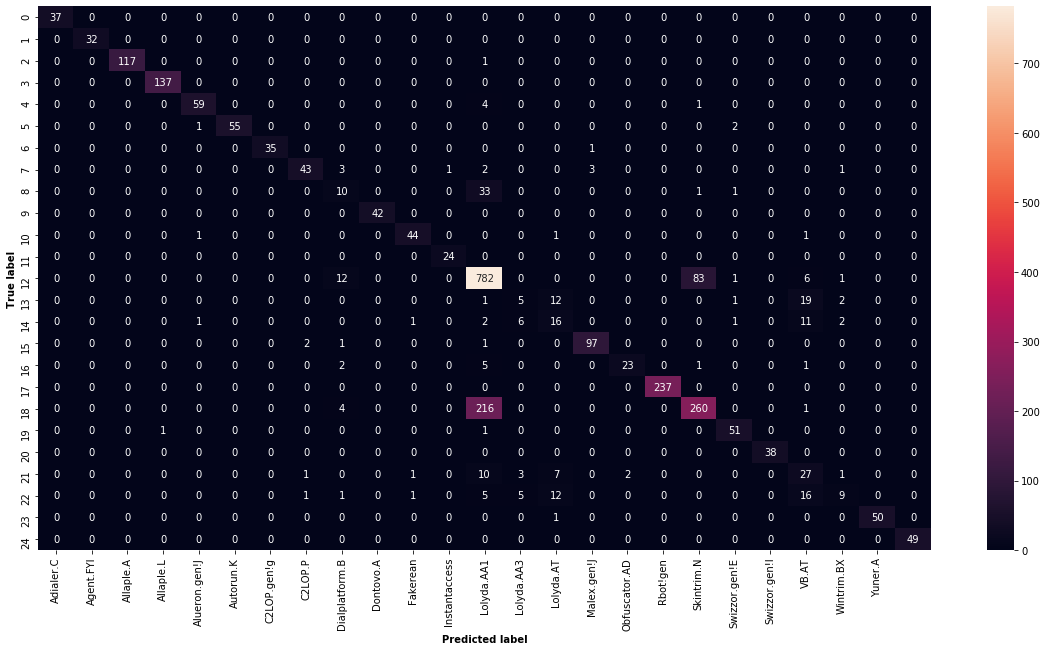

In [66]:
import seaborn as sns
x_axis_labels = ['Adialer.C','Agent.FYI','Allaple.A','Allaple.L','Alueron.gen!J','Autorun.K',
              'C2LOP.gen!g','C2LOP.P','Dialplatform.B','Dontovo.A','Fakerean','Instantaccess',
              'Lolyda.AA1','Lolyda.AA2','Lolyda.AA3','Lolyda.AT','Malex.gen!J','Obfuscator.AD','Rbot!gen',
              'Skintrim.N','Swizzor.gen!E','Swizzor.gen!I','VB.AT','Wintrim.BX','Yuner.A']

y_axis_labels = ['Adialer.C','Agent.FYI','Allaple.A','Allaple.L','Alueron.gen!J','Autorun.K',
              'C2LOP.gen!g','C2LOP.P','Dialplatform.B','Dontovo.A','Fakerean','Instantaccess',
              'Lolyda.AA1','Lolyda.AA2','Lolyda.AA3','Lolyda.AT','Malex.gen!J','Obfuscator.AD','Rbot!gen',
              'Skintrim.N','Swizzor.gen!E','Swizzor.gen!I','VB.AT','Wintrim.BX','Yuner.A']

fig = plt.figure(figsize=(20,10))
heatmap = sns.heatmap(tl_reasults, annot=True, fmt="d",
                      xticklabels=x_axis_labels, 
                      yticklabels=y_axis_labels)
plt.ylabel('True label',fontweight='bold')
plt.xlabel('Predicted label',fontweight='bold')

Text(0.5, 1.0, 'Accuracy Curves')

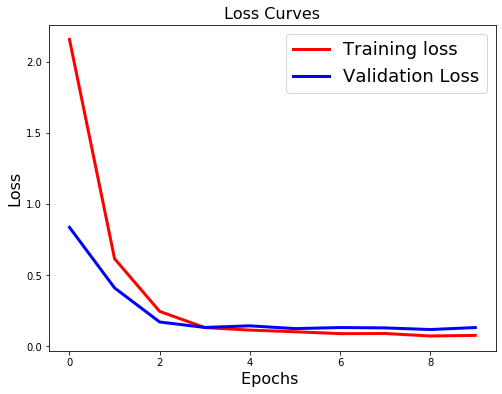

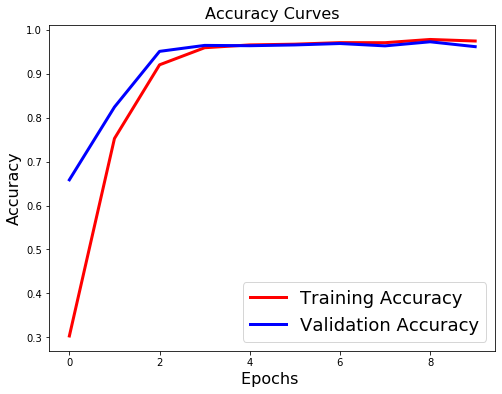

In [60]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)
  
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

**Accuracy Vs Loss Plot**

### -------------------------------------------------------------ResNet-------------------------------------------------------------------------